In [1]:
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np

In [2]:
DICT = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_APRILTAG_16H5)

In [3]:
def page_setup():
    # Source - https://stackoverflow.com/a
    # Posted by Mahmoud, modified by community. See post 'Timeline' for change history
    # Retrieved 2025-11-20, License - CC BY-SA 4.0
    # This example fits a4 paper with 5mm margin printers

    # figure settings
    figure_width = 28.7 # cm
    figure_height = 20 # cm
    left_right_margin = 1 # cm
    top_bottom_margin = 1 # cm
    # standard a4 paper is 21 cm x 29.7cm

    left   = left_right_margin / figure_width # Percentage from height
    bottom = top_bottom_margin / figure_height # Percentage from height
    width  = 1 - left*2
    height = 1 - bottom*2
    cm2inch = 1/2.54 # inch per cm

    fig = plt.figure(figsize=(figure_width*cm2inch,figure_height*cm2inch))
    ax = fig.add_axes((left, bottom, width, height))
    scaler = 72*cm2inch

    plt.xlim(0, figure_width * width)
    plt.ylim(0, figure_height * height)

    return fig, ax, scaler


In [6]:
def create_codes(dictionary = DICT, id= 0, scalar = 2):
    return cv.aruco.generateImageMarker(dictionary = dictionary, id= id, sidePixels = 38*scalar)

def placement(fig, scalar, code, xcoord, ycoord):
    marginx= scalar*1.3
    marginy= scalar*1.2
    adjustedx= marginx+ xcoord*scalar*1.39
    adjustedy= marginy + ycoord*scalar*1.385
    fig.figimage(code,xo= adjustedx, yo= adjustedy, cmap="grey")

def corners(fig, scalar, code_a, code_b):
    placement(fig,scalar, code_a, 0,0)
    placement(fig, scalar, code_b, 22,13.5)

def new_paper(id_a, id_b, save_path= "generic_paper.pdf"):
    fig, _, scalar = page_setup()
    plt.axis('off')
    corners(fig, scalar, create_codes(id = id_a, scalar = 4), create_codes(id = id_b, scalar = 4))
    fig.savefig(save_path)

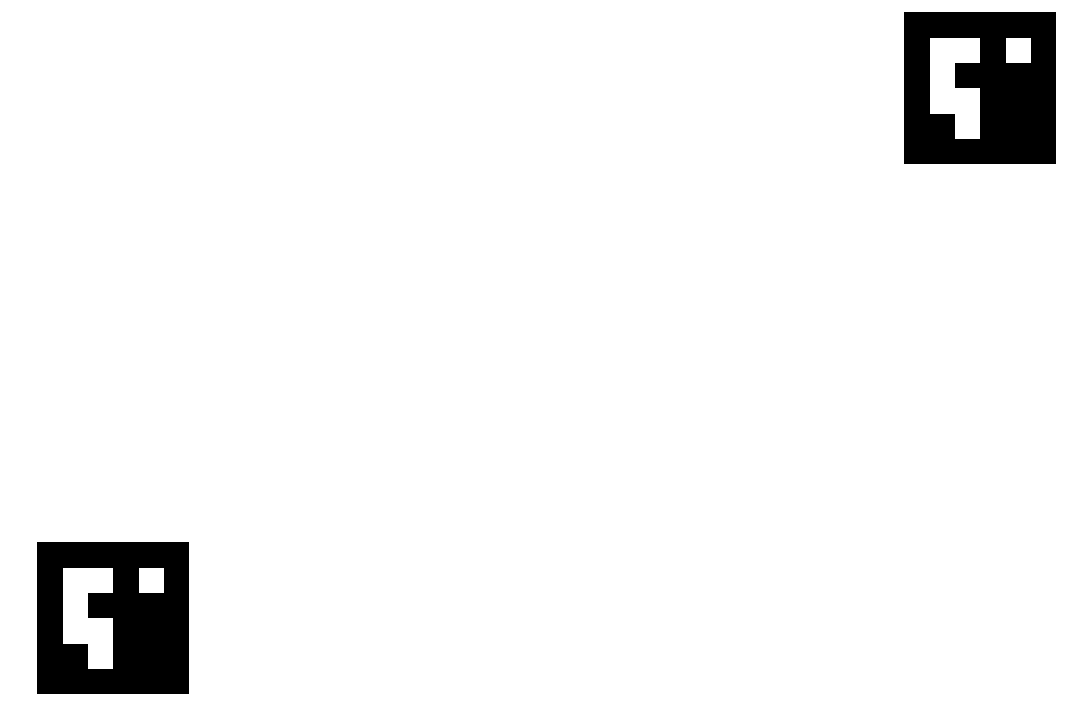

In [7]:
new_paper(0,0, "paper_0_0.pdf")